# Customer Segmentation: B2B & B2C
**UK Online Retail Dataset | Dec 2010 – Dec 2011**

---

## Business Context

The EDA notebook established that this retailer serves two structurally different customer types:

| Metric | B2B (Wholesale) | B2C (Retail) |
|---|---|---|
| Customers | 653 (15%) | 3,686 (85%) |
| Revenue share | 42.3% — £3.69M | 57.7% — £5.04M |
| Avg line item value | £99.50 | £14.44 |
| Classification rule | Mean qty/line **> 20** | Mean qty/line **≤ 20** |
| Churn window | 60 days | 90 days |

Treating them the same would mask wholesale churn, misprice promotions, and waste retention budget on fundamentally different buying cycles.

## Methodology

1. **Data cleaning** — Replicate EDA pipeline (exact duplicates → drop; split line items → aggregate; returns, fees, anonymous rows → exclude)
2. **RFM feature engineering** — Recency, Frequency, Monetary + Average Order Value + Customer Tenure
3. **Quintile scoring** — RFM scores 1–5 within each segment independently
4. **K-Means clustering** — Optimal k via Elbow method + Silhouette score; log1p transform + StandardScaler before fit
5. **Segment labeling** — Ranked by composite RFM centroid; mapped to business-meaningful names
6. **Actionable playbook** — Specific retention and growth actions per segment

---
## 1. Setup & Configuration

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


In [41]:
# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_STATE   = 42           # reproducibility
SNAPSHOT_DATE  = pd.Timestamp('2011-12-10')  # 1 day after last transaction
B2B_THRESHOLD  = 20           # mean qty/line above this → wholesale behaviour
B2C_CHURN_DAYS = 90           # B2C: silent for 90+ days → at risk
B2B_CHURN_DAYS = 60           # B2B: faster reorder cycle → at risk at 60 days
K_B2C          = 4            # cluster count for B2C (confirmed by silhouette)
K_B2B          = 3            # cluster count for B2B (confirmed by silhouette)

# Segment colour palettes
B2C_COLORS = {
    'Champions':       '#27ae60',
    'Loyal Customers': '#2980b9',
    'At Risk':         '#e67e22',
    'Hibernating':     '#c0392b',
}
B2B_COLORS = {
    'Strategic Accounts': '#1a237e',
    'Core Wholesalers':   '#1565c0',
    'Lapsed Accounts':    '#607d8b',
}

NON_PRODUCT = {'AMAZONFEE', 'B', 'M', 'S', 'BANK CHARGES', 'POST', 'D', 'DOT'}
GROUP_KEYS  = ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate',
               'UnitPrice', 'CustomerID', 'Country']


In [42]:
import os
os.getcwd()

'/Users/woodoooo/UK_E-Commerce_Retail_Analysis/03 Scripts'

---
## 2. Data Loading & Cleaning

Replicating the EDA cleaning pipeline exactly — any deviation would produce a different customer universe and invalidate the B2B/B2C split thresholds established there.

**Steps:**
- Parse `InvoiceDate` and cast `CustomerID` to nullable integer
- Drop 5,268 exact full-row duplicates (pipeline re-ingestion artefacts)
- Aggregate 5,416 split line-item rows (same item, different qty entries on one invoice) via `sum(Quantity)`
- Exclude cancellations (`Quantity < 0`), zero/negative prices, non-product stock codes, and anonymous transactions (`CustomerID = NaN`)

In [43]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('../03_Data/Original Data/OnlineRetail.csv', encoding='latin-1')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df['CustomerID']  = df['CustomerID'].astype('Int32')   # nullable integer

# ── Step 1: Drop exact duplicates ─────────────────────────────────────────────
df = df.drop_duplicates()

# ── Step 2: Aggregate split line items ────────────────────────────────────────
df = (
    df
    .groupby(GROUP_KEYS, as_index=False, dropna=False)
    .agg({'Quantity': 'sum'})
)

# ── Step 3: Filter to clean sales only (identified customers) ─────────────────
sales = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (~df['StockCode'].isin(NON_PRODUCT)) &
    (~df['StockCode'].str.startswith('C', na=False)) &
    (df['CustomerID'].notna())
].copy()

sales['Revenue'] = sales['Quantity'] * sales['UnitPrice']

print(f'Clean sales rows:   {len(sales):,}')
print(f'Unique customers:   {sales["CustomerID"].nunique():,}')
print(f'Date range:         {sales["InvoiceDate"].min().date()} to {sales["InvoiceDate"].max().date()}')
print(f'Total revenue:      £{sales["Revenue"].sum():,.0f}')

Clean sales rows:   386,403
Unique customers:   4,334
Date range:         2010-12-01 to 2011-12-09
Total revenue:      £8,737,228


---
## 3. Feature Engineering

### 3.1 Customer Profile

Aggregate per customer: mean line quantity (for B2B/B2C classification), total revenue, order count, product breadth, and primary country.

### 3.2 RFM Features

| Feature | Definition | Direction |
|---|---|---|
| **Recency** | Days since last purchase (relative to 2011-12-10) | Lower = better |
| **Frequency** | Count of unique invoices | Higher = better |
| **Monetary** | Total revenue (£) | Higher = better |
| **AOV** | Monetary / Frequency | Context metric |
| **Tenure** | Days from first to last purchase | Loyalty signal |

> **Why log-transform?** Frequency and monetary are heavily right-skewed (a few bulk buyers dominate). Log1p compression prevents large-value customers from pulling cluster centroids and ensures K-Means distance geometry is meaningful.

In [44]:
# ── Customer-level aggregates ──────────────────────────────────────────────────
customer_profile = (
    sales
    .groupby('CustomerID')
    .agg(
        mean_qty        = ('Quantity', 'mean'),
        total_revenue   = ('Revenue', 'sum'),
        order_count     = ('InvoiceNo', 'nunique'),
        unique_products = ('StockCode', 'nunique'),
        primary_country = ('Country', lambda x: x.mode()[0]),
    )
    .reset_index()
)

# B2B / B2C classification (threshold from EDA: mean qty/line > 20 = wholesale)
customer_profile['CustomerType'] = customer_profile['mean_qty'].apply(
    lambda x: 'B2B' if x > B2B_THRESHOLD else 'B2C'
)

seg_counts = customer_profile['CustomerType'].value_counts()
print('Customer type distribution:')
print(seg_counts)
print(f'\nB2B share: {seg_counts["B2B"] / len(customer_profile):.1%}')

Customer type distribution:
CustomerType
B2C    3676
B2B     658
Name: count, dtype: int64

B2B share: 15.2%


In [45]:
# ── RFM + extended metrics per customer ───────────────────────────────────────
rfm_raw = (
    sales
    .groupby('CustomerID')
    .agg(
        last_purchase  = ('InvoiceDate', 'max'),
        first_purchase = ('InvoiceDate', 'min'),
        frequency      = ('InvoiceNo', 'nunique'),
        monetary       = ('Revenue', 'sum'),
    )
    .reset_index()
)

rfm_raw['recency']     = (SNAPSHOT_DATE - rfm_raw['last_purchase']).dt.days
rfm_raw['aov']         = rfm_raw['monetary'] / rfm_raw['frequency']           # avg order value
rfm_raw['tenure_days'] = (rfm_raw['last_purchase'] - rfm_raw['first_purchase']).dt.days
rfm_raw = rfm_raw.drop(columns=['last_purchase', 'first_purchase'])

# Merge customer type and geography
rfm_raw = rfm_raw.merge(
    customer_profile[['CustomerID', 'CustomerType', 'primary_country', 'unique_products']],
    on='CustomerID'
)

print(f'RFM table: {rfm_raw.shape}')
rfm_raw[['recency', 'frequency', 'monetary', 'aov', 'tenure_days']].describe().round(1)

RFM table: (4334, 9)


,recency,frequency,monetary,aov,tenure_days
count,4334.00,4334.00,4334.00,4334.00,4334.00
mean,92.20,4.20,2016.00,415.50,130.30
std,100.20,7.60,8903.70,1800.90,132.10
min,0.00,1.00,3.80,3.80,0.00
25%,17.00,1.00,304.20,177.20,0.00
50%,50.00,2.00,662.60,289.60,92.00
75%,142.00,5.00,1631.60,423.40,252.00
max,373.00,206.00,279138.00,84236.20,373.00


In [46]:
# ── Quintile-based RFM scoring (1=worst, 5=best), scored within each segment ──
def rfm_quintile_score(df):
    'Add R/F/M scores 1-5 within each CustomerType independently.'
    result = []
    for _, group in df.groupby('CustomerType'):
        g = group.copy()
        try:
            g['R_score'] = pd.qcut(g['recency'],  q=5, labels=[5,4,3,2,1], duplicates='drop').astype(float)
        except ValueError:
            g['R_score'] = 3.0
        try:
            g['F_score'] = pd.qcut(g['frequency'], q=5, labels=[1,2,3,4,5], duplicates='drop').astype(float)
        except ValueError:
            g['F_score'] = 3.0
        try:
            g['M_score'] = pd.qcut(g['monetary'],  q=5, labels=[1,2,3,4,5], duplicates='drop').astype(float)
        except ValueError:
            g['M_score'] = 3.0
        g['RFM_total'] = g['R_score'] + g['F_score'] + g['M_score']  # 3–15
        result.append(g)
    return pd.concat(result, ignore_index=True)

rfm_scored = rfm_quintile_score(rfm_raw)

# Split into B2C and B2B working tables
b2c_rfm = rfm_scored[rfm_scored['CustomerType'] == 'B2C'].copy().reset_index(drop=True)
b2b_rfm = rfm_scored[rfm_scored['CustomerType'] == 'B2B'].copy().reset_index(drop=True)

print(f'B2C: {len(b2c_rfm)} customers   B2B: {len(b2b_rfm)} customers')
print('\nRFM_total distribution (B2C):')
print(b2c_rfm['RFM_total'].describe().round(2))

B2C: 3676 customers   B2B: 658 customers

RFM_total distribution (B2C):
count   3676.00
mean       9.01
std        2.43
min        5.00
25%        7.00
50%        9.00
75%       11.00
max       13.00
Name: RFM_total, dtype: float64


---
## 4. B2B vs B2C — Segment Overview

Before clustering within each segment, confirm the macro split: B2B is a revenue-disproportionate minority.

In [47]:
# Revenue and customer share by type
type_summary = (
    rfm_scored
    .groupby('CustomerType')
    .agg(
        n_customers  = ('CustomerID', 'count'),
        total_rev    = ('monetary', 'sum'),
        median_rev   = ('monetary', 'median'),
        avg_orders   = ('frequency', 'mean'),
        avg_aov      = ('aov', 'mean'),
    )
    .reset_index()
)
type_summary['rev_share_pct'] = type_summary['total_rev'] / type_summary['total_rev'].sum() * 100
type_summary['cust_share_pct'] = type_summary['n_customers'] / type_summary['n_customers'].sum() * 100

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Customer Count', 'Revenue Share (£)', 'Avg Order Value (£)')
)

colors_map = {'B2B': '#1a237e', 'B2C': '#2980b9'}
colors_list = [colors_map[t] for t in type_summary['CustomerType']]

fig.add_trace(go.Bar(
    x=type_summary['CustomerType'], y=type_summary['n_customers'],
    marker_color=colors_list, text=type_summary['n_customers'],
    texttemplate='%{text:,}', textposition='outside', showlegend=False
), row=1, col=1)

fig.add_trace(go.Bar(
    x=type_summary['CustomerType'], y=type_summary['total_rev'],
    marker_color=colors_list, text=type_summary['total_rev'],
    texttemplate='£%{text:,.0f}', textposition='outside', showlegend=False
), row=1, col=2)

fig.add_trace(go.Bar(
    x=type_summary['CustomerType'], y=type_summary['avg_aov'],
    marker_color=colors_list, text=type_summary['avg_aov'],
    texttemplate='£%{text:,.0f}', textposition='outside', showlegend=False
), row=1, col=3)

fig.update_layout(
    title=dict(text='B2B vs B2C: Customer Base Overview', font=dict(size=16)),
    template='plotly_white', height=420,
    margin=dict(t=80)
)
fig.show()

print(type_summary[['CustomerType','n_customers','cust_share_pct','total_rev','rev_share_pct','avg_aov']].to_string(index=False))

CustomerType  n_customers  cust_share_pct  total_rev  rev_share_pct  avg_aov
         B2B          658           15.18 3703012.86          42.38   900.11
         B2C         3676           84.82 5034214.78          57.62   328.74


---
## 5. B2C Customer Segmentation

**3,686 retail customers** | Churn window: 90 days | Target clusters: k=4

### 5.1 RFM Distribution Analysis

Before clustering, understand the shape of the B2C RFM distributions. Skewed distributions confirm the need for log-transformation before K-Means.

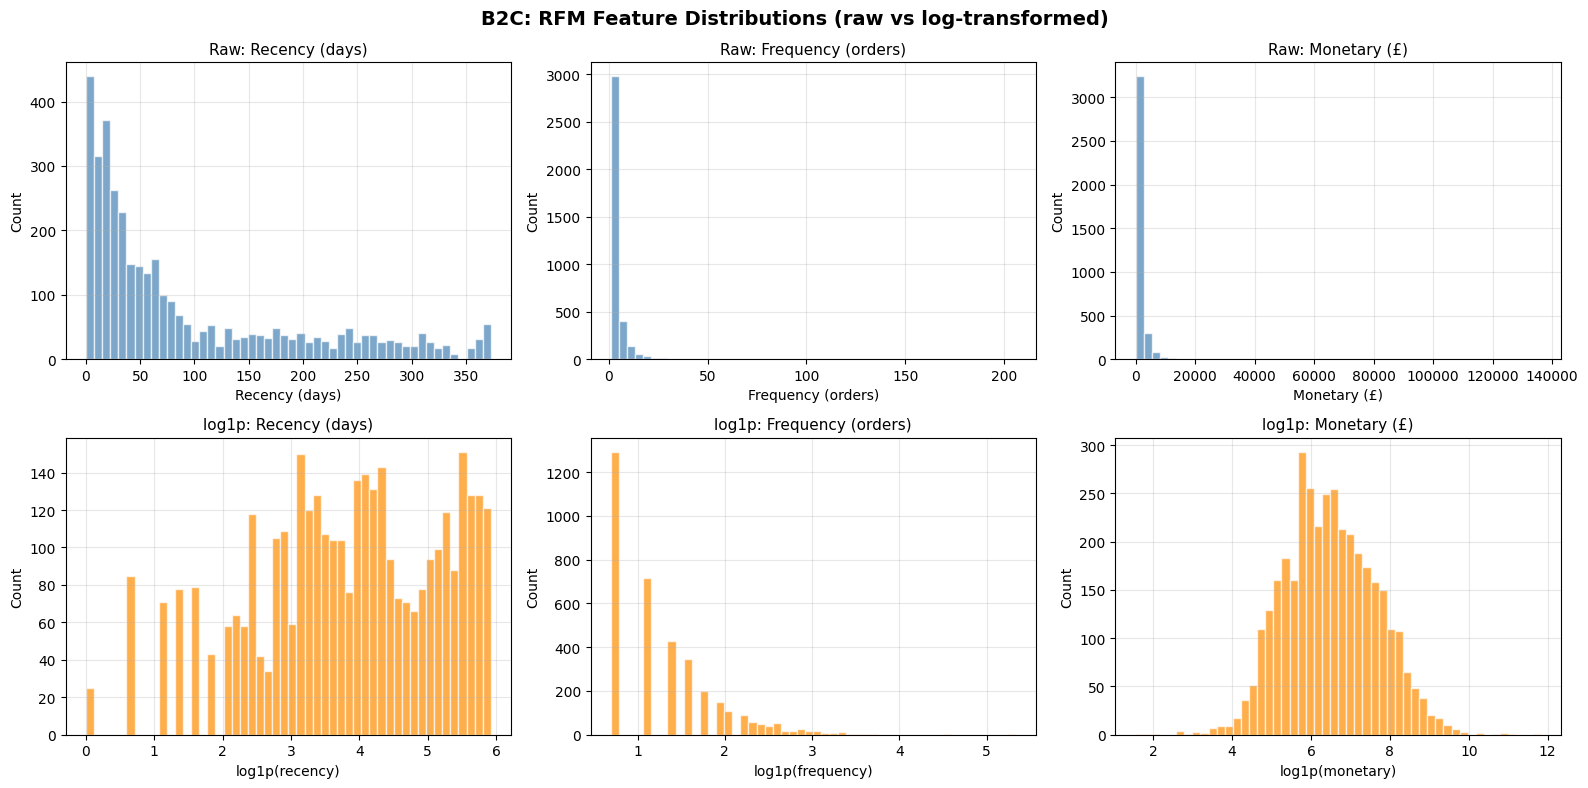

B2C RFM summary stats:
       recency  frequency  monetary     aov
count  3676.00    3676.00   3676.00 3676.00
mean     92.30       4.00   1369.50  328.70
std     100.80       7.20   3427.80  270.70
min       0.00       1.00      3.80    3.80
25%      17.00       1.00    295.00  173.30
50%      50.00       2.00    623.70  271.10
75%     147.00       4.00   1474.70  400.00
max     373.00     206.00 136161.80 4873.80


In [48]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('B2C: RFM Feature Distributions (raw vs log-transformed)', fontsize=14, fontweight='bold')

features = ['recency', 'frequency', 'monetary']
labels   = ['Recency (days)', 'Frequency (orders)', 'Monetary (£)']

for i, (feat, label) in enumerate(zip(features, labels)):
    # Raw
    axes[0, i].hist(b2c_rfm[feat], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'Raw: {label}', fontsize=11)
    axes[0, i].set_xlabel(label)
    axes[0, i].set_ylabel('Count')
    axes[0, i].grid(True, alpha=0.3)

    # Log-transformed
    axes[1, i].hist(np.log1p(b2c_rfm[feat]), bins=50, color='darkorange', alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'log1p: {label}', fontsize=11)
    axes[1, i].set_xlabel(f'log1p({feat})')
    axes[1, i].set_ylabel('Count')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('B2C RFM summary stats:')
print(b2c_rfm[['recency', 'frequency', 'monetary', 'aov']].describe().round(1).to_string())

### 5.2 Optimal Number of Clusters

Two diagnostics:
- **Elbow method** — Plot inertia (within-cluster SSE) vs k. The 'elbow' marks diminishing returns.
- **Silhouette score** — Measures cluster cohesion and separation. Higher = better defined clusters.

Both methods inform the final k choice. Business interpretability is also a constraint — more than 5 segments becomes hard to act on.

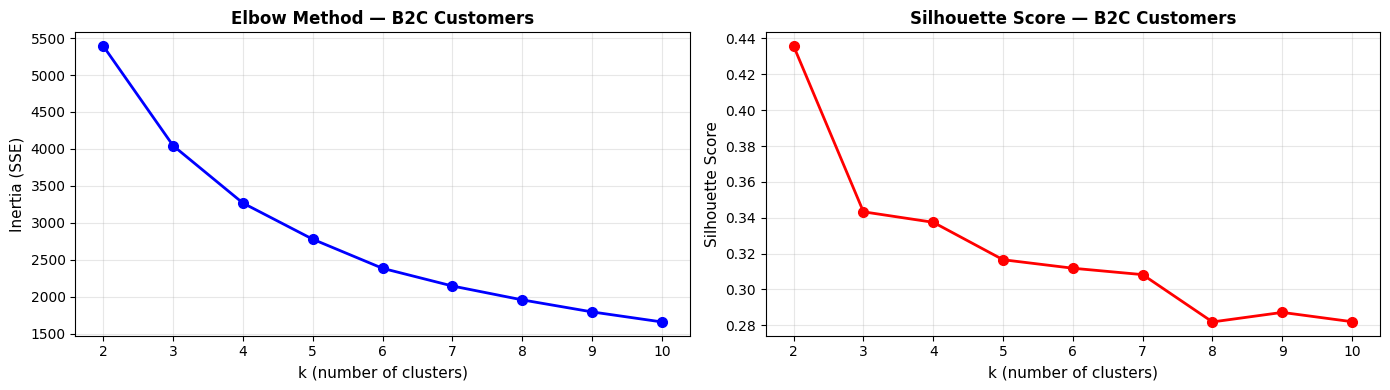

Best k by silhouette: 2  (score: 0.4357)


In [49]:
# ── Prepare B2C feature matrix ─────────────────────────────────────────────────
CLUSTER_FEATURES = ['recency', 'frequency', 'monetary']

def prepare_kmeans(df, features=CLUSTER_FEATURES):
    'Log1p-transform + StandardScale RFM features. Returns scaled array + fitted scaler.'
    X = df[features].copy().astype(float)
    X = np.log1p(X)                                # compress skew
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler

def elbow_silhouette(X_scaled, max_k=10, title=''):
    'Plot Elbow + Silhouette and return scores.'
    inertias, silhouettes = [], []
    K = range(2, max_k + 1)
    for k in K:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(list(K), inertias, 'bo-', linewidth=2, markersize=7)
    ax1.set_xlabel('k (number of clusters)', fontsize=11)
    ax1.set_ylabel('Inertia (SSE)', fontsize=11)
    ax1.set_title(f'Elbow Method — {title}', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.plot(list(K), silhouettes, 'ro-', linewidth=2, markersize=7)
    ax2.set_xlabel('k (number of clusters)', fontsize=11)
    ax2.set_ylabel('Silhouette Score', fontsize=11)
    ax2.set_title(f'Silhouette Score — {title}', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_k = list(K)[int(np.argmax(silhouettes))]
    print(f'Best k by silhouette: {best_k}  (score: {max(silhouettes):.4f})')
    return inertias, silhouettes

X_b2c, scaler_b2c = prepare_kmeans(b2c_rfm)
_, _ = elbow_silhouette(X_b2c, max_k=10, title='B2C Customers')

### 5.3 K-Means Clustering — B2C (k=4)

**k=4** balances statistical fit with business usability:
- Champions — recent, frequent, high spend
- Loyal Customers — regular buyers, solid monetary
- At Risk — lapsing high-value customers
- Hibernating — inactive low-value customers

Clusters are labeled by sorting on mean RFM_total — a composite score that integrates all three dimensions.

In [50]:
# ── Fit K-Means (B2C) ─────────────────────────────────────────────────────────
km_b2c = KMeans(n_clusters=K_B2C, random_state=RANDOM_STATE, n_init=10)
b2c_rfm['Cluster'] = km_b2c.fit_predict(X_b2c)

# Rank clusters by mean RFM_total (highest = Champions)
cluster_rank_b2c = (
    b2c_rfm.groupby('Cluster')['RFM_total']
    .mean()
    .sort_values(ascending=False)
)

B2C_SEGMENT_NAMES = ['Champions', 'Loyal Customers', 'At Risk', 'Hibernating']
b2c_label_map = dict(zip(cluster_rank_b2c.index, B2C_SEGMENT_NAMES))
b2c_rfm['Segment'] = b2c_rfm['Cluster'].map(b2c_label_map)

print('B2C cluster → segment mapping:')
for cluster, segment in b2c_label_map.items():
    mean_score = cluster_rank_b2c[cluster]
    n = (b2c_rfm['Cluster'] == cluster).sum()
    print(f'  Cluster {cluster} → {segment:20s}  n={n:4d}  mean RFM_total={mean_score:.2f}')

B2C cluster → segment mapping:
  Cluster 2 → Champions             n= 602  mean RFM_total=12.46
  Cluster 1 → Loyal Customers       n=1003  mean RFM_total=9.94
  Cluster 3 → At Risk               n= 729  mean RFM_total=9.60
  Cluster 0 → Hibernating           n=1342  mean RFM_total=6.46


### 5.4 B2C Segment Profiles

The profile table is the core output — it drives the business action plan. Read it as: for each segment, what is the typical customer's behaviour, and how large is the commercial opportunity?

In [51]:
# ── Compute segment profiles ───────────────────────────────────────────────────
b2c_profile = (
    b2c_rfm.groupby('Segment')
    .agg(
        n_customers   = ('CustomerID', 'count'),
        avg_recency   = ('recency',   'mean'),
        avg_frequency = ('frequency', 'mean'),
        avg_monetary  = ('monetary',  'mean'),
        avg_aov       = ('aov',       'mean'),
        avg_tenure    = ('tenure_days','mean'),
        total_revenue = ('monetary',  'sum'),
    )
    .reset_index()
)

b2c_profile['cust_share_pct'] = (
    b2c_profile['n_customers'] / b2c_profile['n_customers'].sum() * 100
).round(1)
b2c_profile['rev_share_pct'] = (
    b2c_profile['total_revenue'] / b2c_profile['total_revenue'].sum() * 100
).round(1)

# Order by monetary descending
b2c_profile = b2c_profile.sort_values('avg_monetary', ascending=False)

# Display-friendly formatting
disp = b2c_profile.copy()
disp['avg_recency']   = disp['avg_recency'].round(0).astype(int).astype(str) + ' days'
disp['avg_frequency'] = disp['avg_frequency'].round(1)
disp['avg_monetary']  = disp['avg_monetary'].map('£{:,.0f}'.format)
disp['avg_aov']       = disp['avg_aov'].map('£{:,.0f}'.format)
disp['avg_tenure']    = disp['avg_tenure'].round(0).astype(int).astype(str) + ' days'
disp['total_revenue'] = disp['total_revenue'].map('£{:,.0f}'.format)
disp['cust_share_pct'] = disp['cust_share_pct'].astype(str) + '%'
disp['rev_share_pct']  = disp['rev_share_pct'].astype(str) + '%'

print('B2C SEGMENT PROFILES')
print('=' * 100)
display(disp[['Segment','n_customers','cust_share_pct','avg_recency','avg_frequency',
              'avg_monetary','avg_aov','avg_tenure','total_revenue','rev_share_pct']]
        .set_index('Segment'))

B2C SEGMENT PROFILES


,n_customers,cust_share_pct,avg_recency,avg_frequency,avg_monetary,avg_aov,avg_tenure,total_revenue,rev_share_pct
Segment,,,,,,,,,
Champions,602,16.4%,12 days,12.30,"£4,635",£394,294 days,"£2,790,430",55.4%
Loyal Customers,1003,27.3%,67 days,4.00,"£1,459",£416,194 days,"£1,463,343",29.1%
At Risk,729,19.8%,20 days,2.00,£488,£274,95 days,"£355,425",7.1%
Hibernating,1342,36.5%,187 days,1.30,£317,£264,24 days,"£425,018",8.4%


### 5.5 B2C Segment Visualisations

In [52]:
# ── Radar chart: RFM profile per segment ─────────────────────────────────────
# Normalise mean R/F/M scores to 0–100 for visual comparison
radar_data = b2c_rfm.groupby('Segment')[['R_score', 'F_score', 'M_score']].mean()
radar_norm = (radar_data - 1.0) / 4.0 * 100.0   # map 1–5 → 0–100

categories = ['Recency', 'Frequency', 'Monetary']
theta      = categories + [categories[0]]          # close the polygon

fig = go.Figure()
seg_order = ['Champions', 'Loyal Customers', 'At Risk', 'Hibernating']

for seg in seg_order:
    if seg not in radar_norm.index:
        continue
    vals = list(radar_norm.loc[seg]) + [radar_norm.loc[seg].iloc[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=theta, fill='toself', name=seg,
        line=dict(color=B2C_COLORS[seg], width=2),
        fillcolor=B2C_COLORS[seg], opacity=0.2,
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title=dict(text='B2C Segments: RFM Profiles (Normalised to 0–100)', font=dict(size=15)),
    showlegend=True, height=500, template='plotly_white',
)
fig.show()

In [53]:
# ── Scatter: Recency vs Monetary (size = Frequency) ───────────────────────────
# Sample for performance; all 3,686 points plotted
scatter_df = b2c_rfm.copy()
scatter_df['monetary_log'] = np.log1p(scatter_df['monetary'])

fig = px.scatter(
    scatter_df,
    x='recency',
    y='monetary_log',
    color='Segment',
    size='frequency',
    size_max=20,
    color_discrete_map=B2C_COLORS,
    opacity=0.65,
    labels={
        'recency':     'Recency (days since last purchase)',
        'monetary_log': 'log(Total Revenue £)',
        'frequency':   'Frequency (orders)',
    },
    title='B2C Segments: Recency vs Revenue (bubble size = order frequency)',
    category_orders={'Segment': seg_order},
    hover_data={'recency': True, 'monetary': ':,.0f', 'frequency': True},
)

# Churn threshold line
fig.add_vline(
    x=B2C_CHURN_DAYS, line_dash='dash', line_color='grey',
    annotation_text=f'B2C churn window ({B2C_CHURN_DAYS}d)',
    annotation_position='top right'
)

fig.update_layout(template='plotly_white', height=520)
fig.show()

In [54]:
# ── Bar charts: customer count + revenue share per segment ────────────────────
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Customers per Segment', 'Revenue Share', 'Avg Monetary Value (£)')
)

seg_plot = b2c_profile.sort_values('avg_monetary', ascending=False)
bar_colors = [B2C_COLORS.get(s, '#95a5a6') for s in seg_plot['Segment']]

fig.add_trace(go.Bar(
    x=seg_plot['Segment'], y=seg_plot['n_customers'],
    marker_color=bar_colors, showlegend=False,
    text=seg_plot['n_customers'], textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=seg_plot['Segment'], y=seg_plot['rev_share_pct'],
    marker_color=bar_colors, showlegend=False,
    text=seg_plot['rev_share_pct'], texttemplate='%{text}%', textposition='outside'
), row=1, col=2)

fig.add_trace(go.Bar(
    x=seg_plot['Segment'], y=b2c_profile.set_index('Segment').loc[seg_plot['Segment'], 'avg_monetary'].values,
    marker_color=bar_colors, showlegend=False,
    text=b2c_profile.set_index('Segment').loc[seg_plot['Segment'], 'avg_monetary'].values,
    texttemplate='£%{text:,.0f}', textposition='outside'
), row=1, col=3)

fig.update_layout(
    title=dict(text='B2C Segment Summary', font=dict(size=16)),
    template='plotly_white', height=450, margin=dict(t=80)
)
fig.show()

In [55]:
# ── Churn risk: At Risk customers above median monetary ───────────────────────
# These are the highest-priority win-back targets
median_monetary_b2c = b2c_rfm['monetary'].median()

at_risk_highvalue = b2c_rfm[
    (b2c_rfm['Segment'] == 'At Risk') &
    (b2c_rfm['monetary'] >= median_monetary_b2c)
].sort_values('monetary', ascending=False)

print(f'Median B2C customer monetary: £{median_monetary_b2c:,.0f}')
print(f'At Risk customers above median: {len(at_risk_highvalue)}')
print(f'Revenue at risk: £{at_risk_highvalue["monetary"].sum():,.0f}')
print()
print('Top 10 At Risk, High-Value B2C customers:')
display(at_risk_highvalue[['CustomerID','recency','frequency','monetary','aov','primary_country']]
        .head(10)
        .rename(columns={'recency':'Days Since Purchase',
                         'frequency':'Orders', 'monetary':'Total £',
                         'aov':'Avg Order £', 'primary_country':'Country'})
        .set_index('CustomerID'))

Median B2C customer monetary: £624
At Risk customers above median: 201
Revenue at risk: £173,384

Top 10 At Risk, High-Value B2C customers:


,Days Since Purchase,Orders,Total £,Avg Order £,Country
CustomerID,,,,,
15123,7,2,2199.31,1099.65,United Kingdom
15531,8,2,1972.39,986.20,United Kingdom
12560,5,2,1918.01,959.00,Germany
12762,7,2,1702.52,851.26,Portugal
14759,4,3,1625.97,541.99,United Kingdom
12381,4,3,1474.81,491.60,Norway
17590,2,3,1466.77,488.92,United Kingdom
12882,9,2,1463.04,731.52,United Kingdom
12349,18,1,1457.55,1457.55,Italy


### 5.6 B2C Key Insights

| Segment | Signal | Priority Action |
|---|---|---|
| **Champions** | Lowest recency, highest frequency + monetary. Core base. | VIP programme, early access, referral ask. Do not over-discount — they buy anyway. |
| **Loyal Customers** | Consistent buyers, solid spend. Champions-in-waiting. | Personalised recommendations, loyalty tier upgrade, frequency nudge (e.g. 'complete your collection'). |
| **At Risk** | Once-valuable, now going quiet. High-value subset is a priority win-back target. | Reactivation email with strong incentive (10–15% off). Time-limit the offer. Escalate high-value cases to personal outreach. |
| **Hibernating** | Low historical value, long silent. Low ROI to chase. | Low-cost reactivation (newsletter, seasonal campaign). Accept ~10–15% recovery rate. Focus spend on the other three segments. |

**Key numbers:**
- Champions + Loyal drive the majority of B2C revenue despite being a minority of customers
- At Risk high-value customers represent recoverable revenue — these should be personalised win-backs, not batch emails
- Hibernating customers should receive low-cost, automated re-engagement only

---
## 6. B2B Customer Segmentation

**653 wholesale customers** | Churn window: 60 days | Target clusters: k=3

B2B customers have fundamentally different dynamics:
- Shorter reorder cycles (60-day churn window vs 90-day)
- Much higher order values (mean AOV ≈ £99 vs £14 B2C)
- Order size variability is much larger (bulk purchasing)
- Country mix may differ (international wholesale customers)

With only 653 customers, 3 clusters is appropriate — a 4th cluster would be too small to act on.

### 6.1 B2B RFM Distribution Analysis

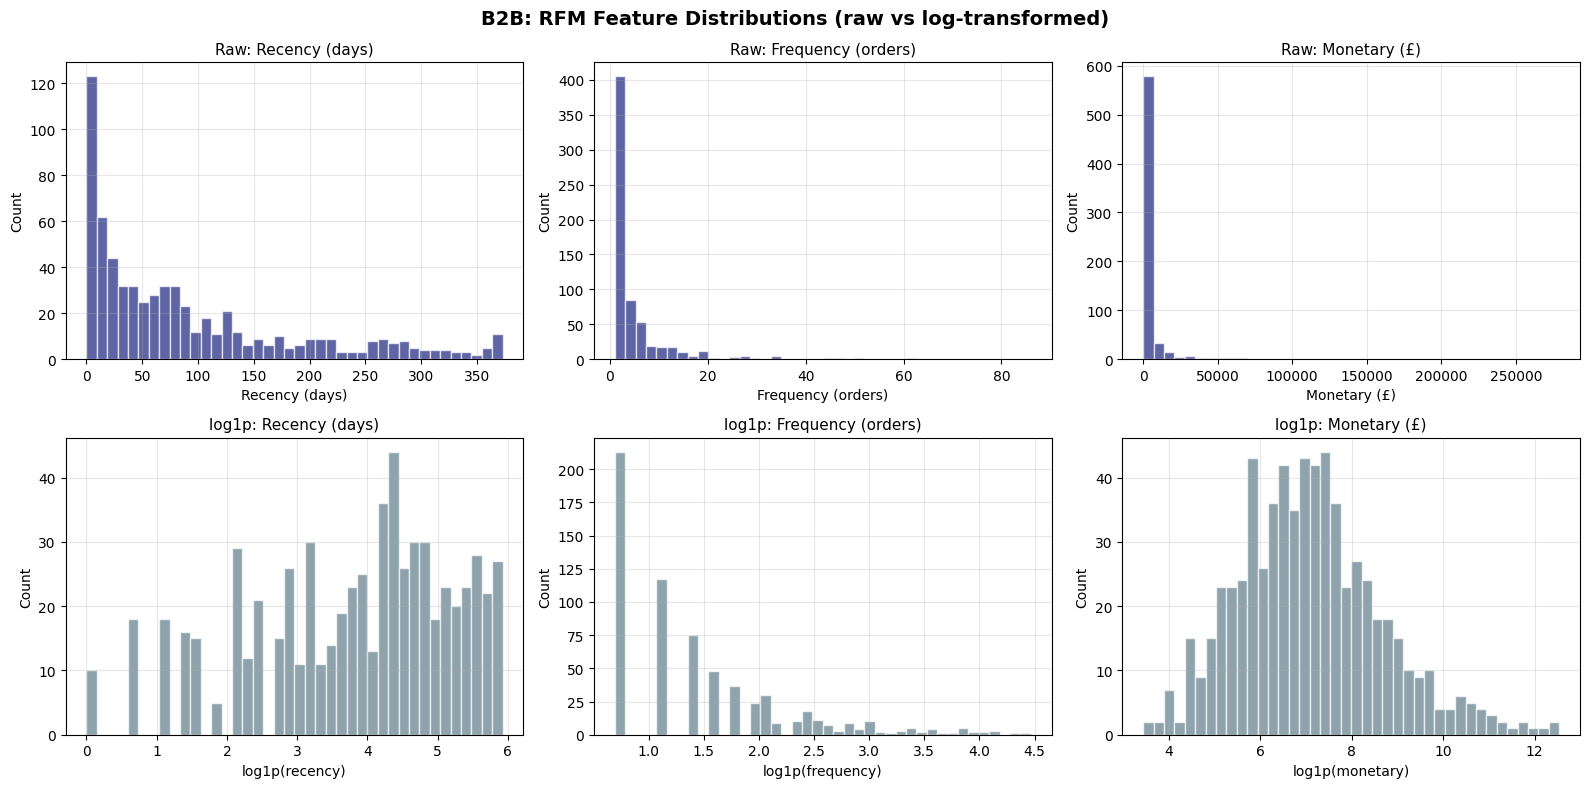

B2B RFM summary stats:
       recency  frequency  monetary      aov
count   658.00     658.00    658.00   658.00
mean     91.90       5.70   5627.70   900.10
std      97.00       9.60  21016.80  4550.00
min       0.00       1.00     30.00    26.00
25%      16.00       1.00    376.70   228.50
50%      59.50       2.00   1061.60   368.60
75%     130.00       6.00   2958.30   641.60
max     373.00      86.00 279138.00 84236.20


In [56]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('B2B: RFM Feature Distributions (raw vs log-transformed)', fontsize=14, fontweight='bold')

for i, (feat, label) in enumerate(zip(features, labels)):
    axes[0, i].hist(b2b_rfm[feat], bins=40, color='#1a237e', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'Raw: {label}', fontsize=11)
    axes[0, i].set_xlabel(label)
    axes[0, i].set_ylabel('Count')
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].hist(np.log1p(b2b_rfm[feat]), bins=40, color='#607d8b', alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'log1p: {label}', fontsize=11)
    axes[1, i].set_xlabel(f'log1p({feat})')
    axes[1, i].set_ylabel('Count')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('B2B RFM summary stats:')
print(b2b_rfm[['recency', 'frequency', 'monetary', 'aov']].describe().round(1).to_string())

### 6.2 Optimal Number of Clusters — B2B

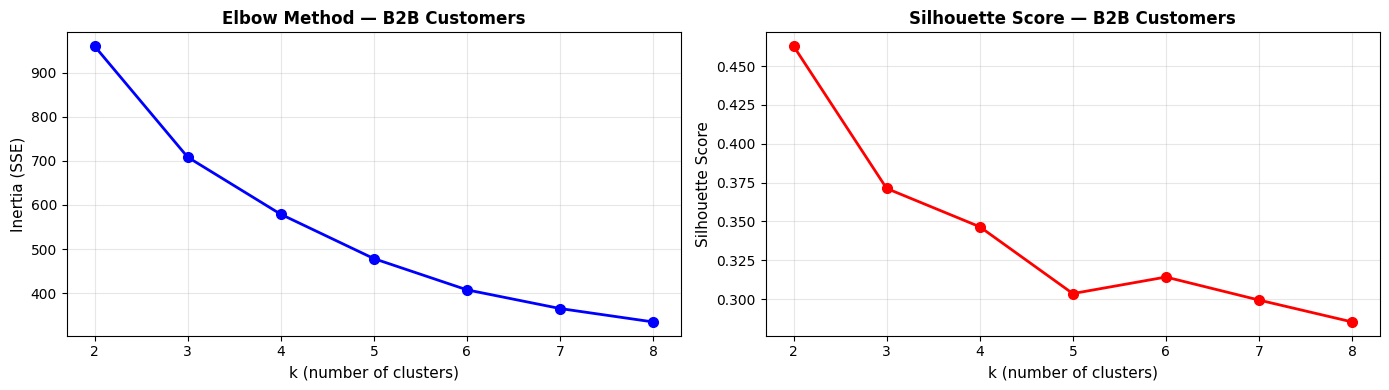

Best k by silhouette: 2  (score: 0.4629)


In [57]:
X_b2b, scaler_b2b = prepare_kmeans(b2b_rfm)
_, _ = elbow_silhouette(X_b2b, max_k=8, title='B2B Customers')

### 6.3 K-Means Clustering — B2B (k=3)

**k=3** reflects the natural wholesale tiers:
- **Strategic Accounts** — high-frequency, high-monetary anchor accounts
- **Core Wholesalers** — regular buyers, consistent contributors
- **Lapsed Accounts** — formerly purchasing, now silent; risk of permanent churn

In [58]:
# ── Fit K-Means (B2B) ─────────────────────────────────────────────────────────
km_b2b = KMeans(n_clusters=K_B2B, random_state=RANDOM_STATE, n_init=10)
b2b_rfm['Cluster'] = km_b2b.fit_predict(X_b2b)

# Rank by mean RFM_total (highest = Strategic Accounts)
cluster_rank_b2b = (
    b2b_rfm.groupby('Cluster')['RFM_total']
    .mean()
    .sort_values(ascending=False)
)

B2B_SEGMENT_NAMES = ['Strategic Accounts', 'Core Wholesalers', 'Lapsed Accounts']
b2b_label_map = dict(zip(cluster_rank_b2b.index, B2B_SEGMENT_NAMES))
b2b_rfm['Segment'] = b2b_rfm['Cluster'].map(b2b_label_map)

print('B2B cluster → segment mapping:')
for cluster, segment in b2b_label_map.items():
    mean_score = cluster_rank_b2b[cluster]
    n = (b2b_rfm['Cluster'] == cluster).sum()
    print(f'  Cluster {cluster} → {segment:22s}  n={n:3d}  mean RFM_total={mean_score:.2f}')

B2B cluster → segment mapping:
  Cluster 0 → Strategic Accounts      n= 77  mean RFM_total=12.82
  Cluster 1 → Core Wholesalers        n=228  mean RFM_total=10.52
  Cluster 2 → Lapsed Accounts         n=353  mean RFM_total=7.22


### 6.4 B2B Segment Profiles

In [59]:
# ── Compute B2B segment profiles ──────────────────────────────────────────────
b2b_profile = (
    b2b_rfm.groupby('Segment')
    .agg(
        n_customers   = ('CustomerID', 'count'),
        avg_recency   = ('recency',    'mean'),
        avg_frequency = ('frequency',  'mean'),
        avg_monetary  = ('monetary',   'mean'),
        avg_aov       = ('aov',        'mean'),
        avg_tenure    = ('tenure_days','mean'),
        total_revenue = ('monetary',   'sum'),
        avg_products  = ('unique_products', 'mean'),
    )
    .reset_index()
)

b2b_profile['cust_share_pct'] = (
    b2b_profile['n_customers'] / b2b_profile['n_customers'].sum() * 100
).round(1)
b2b_profile['rev_share_pct'] = (
    b2b_profile['total_revenue'] / b2b_profile['total_revenue'].sum() * 100
).round(1)

b2b_profile = b2b_profile.sort_values('avg_monetary', ascending=False)

disp_b2b = b2b_profile.copy()
disp_b2b['avg_recency']   = disp_b2b['avg_recency'].round(0).astype(int).astype(str) + ' days'
disp_b2b['avg_frequency'] = disp_b2b['avg_frequency'].round(1)
disp_b2b['avg_monetary']  = disp_b2b['avg_monetary'].map('£{:,.0f}'.format)
disp_b2b['avg_aov']       = disp_b2b['avg_aov'].map('£{:,.0f}'.format)
disp_b2b['avg_tenure']    = disp_b2b['avg_tenure'].round(0).astype(int).astype(str) + ' days'
disp_b2b['total_revenue'] = disp_b2b['total_revenue'].map('£{:,.0f}'.format)
disp_b2b['avg_products']  = disp_b2b['avg_products'].round(0).astype(int)
disp_b2b['cust_share_pct'] = disp_b2b['cust_share_pct'].astype(str) + '%'
disp_b2b['rev_share_pct']  = disp_b2b['rev_share_pct'].astype(str) + '%'

print('B2B SEGMENT PROFILES')
print('=' * 110)
display(disp_b2b[['Segment','n_customers','cust_share_pct','avg_recency','avg_frequency',
                   'avg_monetary','avg_aov','avg_products','avg_tenure',
                   'total_revenue','rev_share_pct']]
        .set_index('Segment'))

B2B SEGMENT PROFILES


,n_customers,cust_share_pct,avg_recency,avg_frequency,avg_monetary,avg_aov,avg_products,avg_tenure,total_revenue,rev_share_pct
Segment,,,,,,,,,,
Strategic Accounts,77,11.7%,7 days,25.60,"£34,136","£2,205",124,338 days,"£2,628,453",71.0%
Core Wholesalers,228,34.7%,43 days,5.40,"£3,678","£1,098",37,210 days,"£838,595",22.6%
Lapsed Accounts,353,53.6%,142 days,1.60,£668,£488,11,50 days,"£235,965",6.4%


### 6.5 B2B Segment Visualisations

In [60]:
# ── Radar chart: B2B segment RFM profiles ────────────────────────────────────
radar_b2b = b2b_rfm.groupby('Segment')[['R_score', 'F_score', 'M_score']].mean()
radar_b2b_norm = (radar_b2b - 1.0) / 4.0 * 100.0

fig_b2b_radar = go.Figure()
b2b_seg_order = ['Strategic Accounts', 'Core Wholesalers', 'Lapsed Accounts']

for seg in b2b_seg_order:
    if seg not in radar_b2b_norm.index:
        continue
    vals = list(radar_b2b_norm.loc[seg]) + [radar_b2b_norm.loc[seg].iloc[0]]
    fig_b2b_radar.add_trace(go.Scatterpolar(
        r=vals, theta=theta, fill='toself', name=seg,
        line=dict(color=B2B_COLORS[seg], width=2),
        fillcolor=B2B_COLORS[seg], opacity=0.25,
    ))

fig_b2b_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title=dict(text='B2B Segments: RFM Profiles (Normalised to 0–100)', font=dict(size=15)),
    showlegend=True, height=500, template='plotly_white',
)
fig_b2b_radar.show()

In [61]:
# ── Scatter: Recency vs Monetary (B2B) ───────────────────────────────────────
b2b_scatter = b2b_rfm.copy()
b2b_scatter['monetary_log'] = np.log1p(b2b_scatter['monetary'])

fig_b2b_scatter = px.scatter(
    b2b_scatter,
    x='recency',
    y='monetary_log',
    color='Segment',
    size='frequency',
    size_max=25,
    color_discrete_map=B2B_COLORS,
    opacity=0.7,
    labels={
        'recency':      'Recency (days since last order)',
        'monetary_log': 'log(Total Revenue £)',
        'frequency':    'Order Frequency',
    },
    title='B2B Segments: Recency vs Revenue (bubble size = order frequency)',
    category_orders={'Segment': b2b_seg_order},
    hover_data={'recency': True, 'monetary': ':,.0f', 'frequency': True, 'aov': ':,.0f'},
)

fig_b2b_scatter.add_vline(
    x=B2B_CHURN_DAYS, line_dash='dash', line_color='grey',
    annotation_text=f'B2B churn window ({B2B_CHURN_DAYS}d)',
    annotation_position='top right'
)

fig_b2b_scatter.update_layout(template='plotly_white', height=520)
fig_b2b_scatter.show()

In [62]:
# ── B2B bar summary ───────────────────────────────────────────────────────────
fig_b2b_bars = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Accounts per Segment', 'Revenue Share', 'Avg Monetary (£)')
)

b2b_seg_plot = b2b_profile.sort_values('avg_monetary', ascending=False)
b2b_bar_colors = [B2B_COLORS.get(s, '#607d8b') for s in b2b_seg_plot['Segment']]

fig_b2b_bars.add_trace(go.Bar(
    x=b2b_seg_plot['Segment'], y=b2b_seg_plot['n_customers'],
    marker_color=b2b_bar_colors, showlegend=False,
    text=b2b_seg_plot['n_customers'], textposition='outside'
), row=1, col=1)

fig_b2b_bars.add_trace(go.Bar(
    x=b2b_seg_plot['Segment'], y=b2b_seg_plot['rev_share_pct'],
    marker_color=b2b_bar_colors, showlegend=False,
    text=b2b_seg_plot['rev_share_pct'], texttemplate='%{text}%', textposition='outside'
), row=1, col=2)

fig_b2b_bars.add_trace(go.Bar(
    x=b2b_seg_plot['Segment'],
    y=b2b_profile.set_index('Segment').loc[b2b_seg_plot['Segment'], 'avg_monetary'].values,
    marker_color=b2b_bar_colors, showlegend=False,
    text=b2b_profile.set_index('Segment').loc[b2b_seg_plot['Segment'], 'avg_monetary'].values,
    texttemplate='£%{text:,.0f}', textposition='outside'
), row=1, col=3)

fig_b2b_bars.update_layout(
    title=dict(text='B2B Segment Summary', font=dict(size=16)),
    template='plotly_white', height=450, margin=dict(t=80)
)
fig_b2b_bars.show()

In [63]:
# ── B2B Lapsed Accounts: revenue at risk ─────────────────────────────────────
# Lapsed accounts that were high-value before going dark
lapsed = b2b_rfm[b2b_rfm['Segment'] == 'Lapsed Accounts'].sort_values('monetary', ascending=False)

print(f'Lapsed B2B accounts:         {len(lapsed)}')
print(f'Total revenue at risk:       £{lapsed["monetary"].sum():,.0f}')
print(f'Avg recency (days):          {lapsed["recency"].mean():.0f}')
print(f'Median recency (days):       {lapsed["recency"].median():.0f}')
print()
print('Top 10 Lapsed B2B accounts by historical value:')
display(lapsed[['CustomerID','recency','frequency','monetary','aov','primary_country']]
        .head(10)
        .rename(columns={
            'recency':'Days Silent', 'frequency':'Orders',
            'monetary':'Historical £', 'aov':'Avg Order £',
            'primary_country':'Country'
        })
        .set_index('CustomerID'))

Lapsed B2B accounts:         353
Total revenue at risk:       £235,965
Avg recency (days):          142
Median recency (days):       113

Top 10 Lapsed B2B accounts by historical value:


,Days Silent,Orders,Historical £,Avg Order £,Country
CustomerID,,,,,
12590,211,1,9341.26,9341.26,Germany
12752,81,1,4366.78,4366.78,Norway
18251,87,1,4314.72,4314.72,United Kingdom
12755,280,2,3811.95,1905.97,Japan
12454,56,1,3528.34,3528.34,Spain
18087,290,1,3202.92,3202.92,United Kingdom
13135,196,1,3096.00,3096.00,United Kingdom
12754,235,3,3010.74,1003.58,Japan
12758,116,2,2791.59,1395.80,Portugal


### 6.6 B2B Key Insights

| Segment | Signal | Priority Action |
|---|---|---|
| **Strategic Accounts** | High frequency + monetary. Anchor accounts — losing one is disproportionately painful. | Assign dedicated account manager. Quarterly business reviews. Volume discounts locked in via annual agreements. Monitor for any recency increase immediately. |
| **Core Wholesalers** | Solid, consistent buyers. Upgrade path to Strategic exists. | Frequency nudge campaigns. Product range expansion pitch (they likely buy narrow). Growth incentive at 20% more volume. |
| **Lapsed Accounts** | Silent for 60+ days. Some have strong historical spend — recoverable if contacted promptly. | Immediate personal outreach for top-10 by historical revenue. Win-back offer (freight credit, extended payment terms). If no response after 2 contacts, deprioritise. |

**Key structural fact:** B2B Strategic Accounts likely represent a Pareto concentration — a small number of accounts account for the majority of B2B revenue. Protecting these is the single highest-ROI retention activity in the business.

---
## 7. Cross-Segment Analysis

### 7.1 Revenue Concentration (Pareto)

Does the 80/20 rule hold? If top 20% of customers generate 80%+ of revenue, the segmentation strategy should weight retention heavily over acquisition.

In [64]:
# ── Revenue Pareto across all identified customers ────────────────────────────
all_customers = rfm_scored.sort_values('monetary', ascending=False).copy()
all_customers['cum_revenue'] = all_customers['monetary'].cumsum()
all_customers['cum_revenue_pct'] = all_customers['cum_revenue'] / all_customers['monetary'].sum() * 100
all_customers['cum_customer_pct'] = (np.arange(1, len(all_customers) + 1) / len(all_customers)) * 100

# Find 80% threshold
idx_80 = (all_customers['cum_revenue_pct'] >= 80).idxmax()
cust_pct_at_80 = all_customers.loc[idx_80, 'cum_customer_pct']

fig_pareto = go.Figure()
fig_pareto.add_trace(go.Scatter(
    x=all_customers['cum_customer_pct'],
    y=all_customers['cum_revenue_pct'],
    mode='lines', name='Cumulative Revenue',
    line=dict(color='#1a237e', width=2.5)
))
fig_pareto.add_hline(y=80, line_dash='dash', line_color='red',
                     annotation_text='80% of revenue',
                     annotation_position='right')
fig_pareto.add_vline(x=cust_pct_at_80, line_dash='dash', line_color='orange',
                     annotation_text=f'{cust_pct_at_80:.1f}% of customers',
                     annotation_position='top left')

fig_pareto.update_layout(
    title=dict(text='Revenue Concentration Curve (All Identified Customers)', font=dict(size=15)),
    xaxis_title='Cumulative % of Customers (ranked by revenue)',
    yaxis_title='Cumulative % of Revenue',
    template='plotly_white', height=450
)
fig_pareto.show()

print(f'Top {cust_pct_at_80:.1f}% of customers generate 80% of revenue')
n_top = int(np.ceil(cust_pct_at_80 / 100 * len(all_customers)))
print(f'That is {n_top} customers out of {len(all_customers):,}')

Top 26.1% of customers generate 80% of revenue
That is 1133 customers out of 4,334


### 7.2 Geographic Breakdown by Segment

Are high-value B2B accounts concentrated in certain countries? Does B2C churn risk vary by geography?

In [65]:
# ── Top countries per B2C segment ─────────────────────────────────────────────
b2c_geo = (
    b2c_rfm.groupby(['Segment', 'primary_country'])
    .agg(n=('CustomerID','count'), revenue=('monetary','sum'))
    .reset_index()
    .sort_values(['Segment','revenue'], ascending=[True, False])
)

# Top 5 countries per B2C segment
b2c_top_geo = b2c_geo.groupby('Segment').head(5)

fig_geo_b2c = px.bar(
    b2c_top_geo,
    x='revenue', y='primary_country', color='Segment',
    facet_col='Segment', facet_col_wrap=2,
    orientation='h',
    color_discrete_map=B2C_COLORS,
    labels={'revenue': 'Revenue (£)', 'primary_country': ''},
    title='B2C: Top Countries by Segment (Revenue)',
)
fig_geo_b2c.update_layout(template='plotly_white', height=600, showlegend=False)
fig_geo_b2c.show()

# B2B: where are Strategic Accounts located?
b2b_geo = (
    b2b_rfm.groupby(['Segment', 'primary_country'])
    .agg(n=('CustomerID','count'), revenue=('monetary','sum'))
    .reset_index()
    .sort_values(['Segment','revenue'], ascending=[True, False])
)
b2b_top_geo = b2b_geo.groupby('Segment').head(5)

print('\nB2B Strategic Accounts by Country:')
strat = b2b_geo[b2b_geo['Segment'] == 'Strategic Accounts']
print(strat[['primary_country','n','revenue']].rename(
    columns={'primary_country':'Country','n':'Accounts','revenue':'Revenue £'}
).head(10).to_string(index=False))


B2B Strategic Accounts by Country:
       Country  Accounts  Revenue £
United Kingdom        70 2037575.52
   Netherlands         1  279138.02
     Australia         1  124564.53
          EIRE         1  116560.08
        Sweden         1   31781.82
        France         2   25457.29
        Norway         1   13375.87


### 7.3 Product Preferences by Segment

Champions and Strategic Accounts have distinct product affinities. Understanding these allows targeted catalogue recommendations and inventory planning.

In [66]:
# ── Merge segments back to transaction data ───────────────────────────────────
b2c_seg_map = b2c_rfm[['CustomerID', 'Segment']].rename(columns={'Segment': 'B2C_Segment'})
b2b_seg_map = b2b_rfm[['CustomerID', 'Segment']].rename(columns={'Segment': 'B2B_Segment'})

sales_segmented = sales.merge(b2c_seg_map, on='CustomerID', how='left')
sales_segmented = sales_segmented.merge(b2b_seg_map, on='CustomerID', how='left')

# Combined segment column
sales_segmented['Segment'] = sales_segmented['B2C_Segment'].combine_first(sales_segmented['B2B_Segment'])

# Top 10 products for Champions vs Strategic Accounts
for seg_name, label in [('Champions', 'B2C Champions'), ('Strategic Accounts', 'B2B Strategic Accounts')]:
    top_prods = (
        sales_segmented[sales_segmented['Segment'] == seg_name]
        .groupby('Description')
        .agg(revenue=('Revenue','sum'), qty=('Quantity','sum'))
        .sort_values('revenue', ascending=False)
        .head(10)
        .reset_index()
    )
    top_prods['revenue'] = top_prods['revenue'].map('£{:,.0f}'.format)
    print(f'\nTop 10 Products — {label}:')
    print(top_prods[['Description','revenue','qty']].to_string(index=False))


Top 10 Products — B2C Champions:
                       Description revenue   qty
          REGENCY CAKESTAND 3 TIER £47,158  4000
WHITE HANGING HEART T-LIGHT HOLDER £29,687 10902
                     PARTY BUNTING £24,043  5155
     ASSORTED COLOUR BIRD ORNAMENT £20,542 12457
           JUMBO BAG RED RETROSPOT £20,216 10101
                RABBIT NIGHT LIGHT £16,927  8781
   PAPER CHAIN KIT 50'S CHRISTMAS  £15,438  5402
                    SPOTTY BUNTING £13,458  2773
     DOORMAT KEEP CALM AND COME IN £12,427  1650
                     CHILLI LIGHTS £11,993  2380

Top 10 Products — B2B Strategic Accounts:
                       Description  revenue   qty
       PAPER CRAFT , LITTLE BIRDIE £168,470 80995
          REGENCY CAKESTAND 3 TIER  £53,430  4863
           JUMBO BAG RED RETROSPOT  £37,826 21701
WHITE HANGING HEART T-LIGHT HOLDER  £32,760 11755
          BLACK RECORD COVER FRAME  £25,472  7508
                     CHILLI LIGHTS  £19,824  4208
      VINTAGE UNION JACK MEMOBOARD

---
## 8. Strategic Recommendations & Action Plan

### B2C Playbook

| Segment | Size | Revenue | Recommended Action | KPI to Track |
|---|---|---|---|---|
| **Champions** | Small | High | VIP programme, early access, referral incentive. No heavy discounting — they buy without it. | Retention rate, referral conversion |
| **Loyal Customers** | Medium | Medium-High | Loyalty tier upgrade prompt. Personalised next-product recommendation (based on purchase history). | Frequency increase, tier upgrade rate |
| **At Risk** | Medium | Medium | Time-limited reactivation email (10–15% off, 7-day expiry). High-value subset (above median £) gets personal outreach. | Reactivation rate, recovered revenue |
| **Hibernating** | Large | Low | Low-cost automated re-engagement (seasonal newsletter). Accept ~10% recovery. Do not over-invest. | Open rate, any purchase |

### B2B Playbook

| Segment | Size | Revenue | Recommended Action | KPI to Track |
|---|---|---|---|---|
| **Strategic Accounts** | Small | Very High | Dedicated account manager. Quarterly business reviews. Annual volume contracts. Immediate alert if recency exceeds 45 days. | Days since last order, contract renewal rate |
| **Core Wholesalers** | Medium | Medium | Growth incentive at +20% volume. Product range expansion pitch. Credit terms review. | Order frequency, SKU breadth |
| **Lapsed Accounts** | Small | Low-Medium | Personal phone/email for top 10 by historical value within 1 week. Win-back offer: freight credit or extended payment terms. 2-touch limit — if no response, deprioritise. | Win-back rate, days to first reorder |

### Monitoring Framework

Segment membership is not static — customers move between segments as their behaviour changes. Recommended cadence:

- **Weekly**: Flag B2B Strategic Accounts exceeding 45-day recency
- **Monthly**: Re-score all B2B RFM and update segment assignments
- **Quarterly**: Re-run K-Means on full B2C population; validate segment stability with silhouette score
- **Annually**: Revisit B2B/B2C threshold (mean qty > 20) — business mix may shift

### Revenue Opportunity Summary

| Action | Target | Estimated Revenue Impact |
|---|---|---|
| Retain B2B Strategic Accounts | Prevent 1 lapse | ~£15–40k per account |
| Reactivate top-20 B2B Lapsed | Win back 30% | Significant given historical value |
| Convert B2C At Risk (high-value) | 20% reactivation | Recoverable segment revenue |
| Upgrade Loyal → Champions | Frequency +1 order | Compounding effect on annual LTV |

In [67]:
# ── Export segmented customer lists ───────────────────────────────────────────
import os

output_dir = '03_Data/Segmented'
os.makedirs(output_dir, exist_ok=True)

# B2C export
b2c_export = b2c_rfm[[
    'CustomerID', 'Segment', 'recency', 'frequency', 'monetary',
    'aov', 'tenure_days', 'R_score', 'F_score', 'M_score', 'RFM_total',
    'primary_country'
]].copy()
b2c_export.to_csv(f'{output_dir}/b2c_segments.csv', index=False)

# B2B export
b2b_export = b2b_rfm[[
    'CustomerID', 'Segment', 'recency', 'frequency', 'monetary',
    'aov', 'tenure_days', 'R_score', 'F_score', 'M_score', 'RFM_total',
    'unique_products', 'primary_country'
]].copy()
b2b_export.to_csv(f'{output_dir}/b2b_segments.csv', index=False)

print(f'Exported to {output_dir}/')
print(f'  b2c_segments.csv  →  {len(b2c_export):,} rows')
print(f'  b2b_segments.csv  →  {len(b2b_export):,} rows')
print('\nDone.')

Exported to 03_Data/Segmented/
  b2c_segments.csv  →  3,676 rows
  b2b_segments.csv  →  658 rows

Done.


In [68]:
# ── Export segments to Prepared Data for Streamlit dashboard ─────────────────
import os

output_dir = os.path.join("..", "03_Data", "Prepared Data")
os.makedirs(output_dir, exist_ok=True)

# B2C segments
b2c_rfm[[
    "CustomerID", "Segment", "recency", "frequency", "monetary",
    "aov", "tenure_days", "R_score", "F_score", "M_score", "RFM_total",
    "primary_country"
]].to_csv(os.path.join(output_dir, "b2c_segments.csv"), index=False)

# B2B segments
b2b_rfm[[
    "CustomerID", "Segment", "recency", "frequency", "monetary",
    "aov", "tenure_days", "R_score", "F_score", "M_score", "RFM_total",
    "unique_products", "primary_country"
]].to_csv(os.path.join(output_dir, "b2b_segments.csv"), index=False)

print(f"Exported to: {os.path.abspath(output_dir)}")
print(f"  b2c_segments.csv  →  {len(b2c_rfm):,} B2C customers")
print(f"  b2b_segments.csv  →  {len(b2b_rfm):,} B2B customers")
print("Done.")

Exported to: /Users/woodoooo/UK_E-Commerce_Retail_Analysis/03_Data/Prepared Data
  b2c_segments.csv  →  3,676 B2C customers
  b2b_segments.csv  →  658 B2B customers
Done.
